# 06 -- CatBoost


Мы решаем регрессию задержки `target_delay_s`; основная метрика -- MAE в секундах.

Здесь я использую более строгий протокол, чем обычный random split:

* в train реальные ТС и synthetic ТС разделены по `tr_id`; synthetic имеют ID `9000000+`;
* test и validate состоят из реальных ТС, причем их `tr_id` уже встречаются в train;
* основной CV поэтому строю внутри реальных ТС блоками по времени;
* вокруг validation блока удаляю train точки того же ТС в радиусе 45 минут -- это покрывает максимальные 30 минут истории признаков и 15 минут prediction horizon;
* synthetic никогда не попадает в validation -- его вес в train подбираю как гиперпараметр;
* `test` не использую ни в Optuna, ни в выборе direct/residual -- открываю его один раз после фиксации модели;
* после этой проверки test можно легально добавить к train и отдельно донастроить финальную модель для hidden validate.

Глобальные `pca_core_*` из `02_feature_engineering.ipynb` в CV не использую: PCA там fit'ился на всем train. Для честной оценки любое обучаемое преобразование должно fit'иться только внутри fold.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold

CAT_SEED = 143
CAT_TUNE_FOLDS = 4
CAT_OOF_FOLDS = 5
CAT_STRESS_FOLDS = 5
CAT_PURGE_MINUTES = 45
CAT_TRIALS_PER_MODE = 50
CAT_FINAL_TRIALS = 25
CAT_MAX_ITERATIONS = 2500
CAT_EARLY_STOPPING = 120
CAT_MODES = ['direct', 'residual']
CAT_SYNTHETIC_WEIGHTS = [0.0, .1, .25, .5, .75, 1.0]
CAT_CLIP_Q = [0.0, .001, .005, .01]

/Users/dvsorochan/Dev/mos-transport-hack-2026/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Данные и audit

CatBoost получает категориальные признаки нативно. Я только привожу их к строкам и фиксирую missing category.

Глобальные PCA признаки исключаю -- деревьям они обычно не нужны, а сохраненные компоненты нарушают строгую fold изоляцию.

In [2]:
cat_features_dir = Path('../dataset/features')

cat_train = pd.read_pickle(cat_features_dir / 'train_features.pkl').reset_index(drop=True)
cat_test = pd.read_pickle(cat_features_dir / 'test_features.pkl').reset_index(drop=True)
cat_validate = pd.read_pickle(cat_features_dir / 'validate_features.pkl').reset_index(drop=True)

cat_saved_features = pd.read_csv(cat_features_dir / 'feature_columns.csv').feature.tolist()
cat_saved_categorical = pd.read_csv(cat_features_dir / 'categorical_features.csv').feature.tolist()

cat_feature_cols = [
    cat_col for cat_col in cat_saved_features
    if not cat_col.startswith('pca_core_')
]
cat_categorical_features = [
    cat_col for cat_col in cat_saved_categorical
    if cat_col in cat_feature_cols
]
cat_numeric_features = [
    cat_col for cat_col in cat_feature_cols
    if cat_col not in cat_categorical_features
    and pd.api.types.is_numeric_dtype(cat_train[cat_col].dtype)
]
cat_model_features = cat_numeric_features + cat_categorical_features

assert not {'target_delay_s', 'target_class'} & set(cat_model_features)
assert not any(cat_col.startswith('pca_core_') for cat_col in cat_model_features)
assert set(cat_train.sample_id).isdisjoint(set(cat_test.sample_id))
assert set(cat_train.sample_id).isdisjoint(set(cat_validate.sample_id))

pd.Series({
    'train_rows': len(cat_train),
    'train_real_rows': (cat_train.tr_id < 9_000_000).sum(),
    'train_synthetic_rows': (cat_train.tr_id >= 9_000_000).sum(),
    'test_rows': len(cat_test),
    'validate_rows': len(cat_validate),
    'numeric_features': len(cat_numeric_features),
    'categorical_features': len(cat_categorical_features),
})

train_rows              4434
train_real_rows         1141
train_synthetic_rows    3293
test_rows                353
validate_rows            151
numeric_features         680
categorical_features      12
dtype: int64

## 2. Leakage safe CV

Основной splitter имитирует структуру hidden validate лучше, чем `GroupKFold`: у каждого реального ТС я делю точки на последовательные временные блоки. Validation fold содержит один блок от каждого реального ТС. Из train дополнительно вычищаю точки того же ТС на 45 минут до и после validation блока.

Synthetic остается только в train. Так Optuna оценивает гиперпараметры на реальных точках, но может решить, помогает ли дополнительная синтетика.

Дополнительно после tuning запускаю `GroupKFold` по реальным `tr_id` как stress-test -- он отвечает на более строгий вопрос о переносе на полностью невиданное ТС, хотя hidden validate устроен не так.

In [3]:
def cat_build_purged_folds(data, n_splits, purge_minutes):
    cat_frame = data[['tr_id', 'T']].copy().reset_index(drop=True)
    cat_frame['T'] = pd.to_datetime(cat_frame['T'])
    cat_frame['is_synthetic'] = cat_frame.tr_id >= 9_000_000
    cat_frame['cv_fold'] = -1

    for cat_tr_id, cat_idx in cat_frame.loc[~cat_frame.is_synthetic].groupby('tr_id').groups.items():
        cat_ordered = cat_frame.loc[cat_idx].sort_values('T').index.to_numpy()
        for cat_fold, cat_chunk in enumerate(np.array_split(cat_ordered, n_splits)):
            cat_frame.loc[cat_chunk, 'cv_fold'] = cat_fold

    cat_folds = []
    cat_purge = pd.Timedelta(minutes=purge_minutes)

    for cat_fold in range(n_splits):
        cat_valid_mask = (~cat_frame.is_synthetic) & (cat_frame.cv_fold == cat_fold)
        cat_train_mask = ~cat_valid_mask

        for cat_tr_id, cat_valid_part in cat_frame.loc[cat_valid_mask].groupby('tr_id'):
            cat_left = cat_valid_part['T'].min() - cat_purge
            cat_right = cat_valid_part['T'].max() + cat_purge
            cat_near_valid = (
                (~cat_frame.is_synthetic)
                & (cat_frame.tr_id == cat_tr_id)
                & cat_frame['T'].between(cat_left, cat_right)
            )
            cat_train_mask &= ~cat_near_valid

        cat_folds.append((
            np.flatnonzero(cat_train_mask.to_numpy()),
            np.flatnonzero(cat_valid_mask.to_numpy())
        ))

    return cat_folds


def cat_build_group_stress_folds(data, n_splits):
    cat_real_idx = np.flatnonzero((data.tr_id < 9_000_000).to_numpy())
    cat_synthetic_idx = np.flatnonzero((data.tr_id >= 9_000_000).to_numpy())
    cat_splitter = GroupKFold(n_splits=n_splits, shuffle=True, random_state=CAT_SEED)
    cat_folds = []

    for cat_real_train_local, cat_real_valid_local in cat_splitter.split(
        cat_real_idx,
        groups=data.iloc[cat_real_idx].tr_id
    ):
        cat_train_idx = np.concatenate([
            cat_real_idx[cat_real_train_local],
            cat_synthetic_idx
        ])
        cat_valid_idx = cat_real_idx[cat_real_valid_local]
        cat_folds.append((cat_train_idx, cat_valid_idx))

    return cat_folds


def cat_check_purged_folds(data, folds, purge_minutes):
    cat_frame = data[['tr_id', 'T']].copy().reset_index(drop=True)
    cat_frame['T'] = pd.to_datetime(cat_frame['T'])
    cat_purge = pd.Timedelta(minutes=purge_minutes)
    cat_rows = []

    for cat_fold, (cat_train_idx, cat_valid_idx) in enumerate(folds):
        cat_train = cat_frame.iloc[cat_train_idx]
        cat_valid = cat_frame.iloc[cat_valid_idx]
        cat_min_gap = np.inf

        for cat_tr_id, cat_valid_part in cat_valid.groupby('tr_id'):
            cat_train_times = cat_train.loc[cat_train.tr_id == cat_tr_id, 'T']
            if len(cat_train_times) == 0:
                continue
            cat_gap = np.abs(
                cat_train_times.to_numpy()[:, None]
                - cat_valid_part['T'].to_numpy()[None, :]
            ).min()
            cat_min_gap = min(cat_min_gap, cat_gap / np.timedelta64(1, 'm'))

        cat_rows.append({
            'fold': cat_fold,
            'train_rows': len(cat_train_idx),
            'valid_rows': len(cat_valid_idx),
            'valid_tr_ids': cat_valid.tr_id.nunique(),
            'min_same_tr_gap_min': cat_min_gap
        })

    cat_result = pd.DataFrame(cat_rows)
    assert (cat_result.min_same_tr_gap_min >= purge_minutes).all()
    return cat_result

In [4]:
cat_tune_folds = cat_build_purged_folds(cat_train, CAT_TUNE_FOLDS, CAT_PURGE_MINUTES)
cat_oof_folds = cat_build_purged_folds(cat_train, CAT_OOF_FOLDS, CAT_PURGE_MINUTES)
cat_stress_folds = cat_build_group_stress_folds(cat_train, CAT_STRESS_FOLDS)
cat_fold_audit = cat_check_purged_folds(cat_train, cat_oof_folds, CAT_PURGE_MINUTES)
cat_fold_audit

,fold,train_rows,valid_rows,valid_tr_ids,min_same_tr_gap_min
0,0,4130,233,13,50.0
1,1,4042,231,13,50.0
2,2,4082,228,13,50.0
3,3,4060,226,13,50.0
4,4,4149,223,13,50.0


## 3. CatBoost input

In [5]:
def cat_prepare_frame(data):
    cat_frame = data[cat_model_features].copy()
    for cat_col in cat_categorical_features:
        cat_frame[cat_col] = (
            cat_frame[cat_col]
            .astype('string')
            .fillna('__missing__')
            .astype(str)
        )
    return cat_frame


def cat_sample_weight(data, synthetic_weight):
    return np.where(
        data.tr_id.to_numpy() >= 9_000_000,
        synthetic_weight,
        1.0
    )


def cat_clip_prediction(prediction, y_train, q):
    if q == 0:
        return prediction
    cat_low, cat_high = y_train.quantile([q, 1 - q])
    return np.clip(prediction, cat_low, cat_high)

In [6]:
cat_x_train = cat_prepare_frame(cat_train)
cat_x_test = cat_prepare_frame(cat_test)
cat_x_validate = cat_prepare_frame(cat_validate)
cat_y_train = cat_train.target_delay_s.astype(float)
cat_y_test = cat_test.target_delay_s.astype(float)
cat_cur_train = cat_train.cur_dev_s.astype(float)
cat_cur_test = cat_test.cur_dev_s.astype(float)
cat_cur_validate = cat_validate.cur_dev_s.astype(float)

## 4. Optuna -- hyperparameter search

На каждом fold CatBoost может построить до 2500 деревьев, но early stopping выбирает фактическое число итераций только по validation этого fold.

Search затрагивает capacity, shrinkage, regularization, subsampling признаков, stochasticity, quantization, boosting scheme, synthetic weight и postprocessing. Целевая функция Optuna -- средний MAE по real validation folds.

In [7]:
def cat_suggest_params(trial):
    return {
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', .01, .18, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 100, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 5),
        'rsm': trial.suggest_float('rsm', .5, 1.0),
        'border_count': trial.suggest_categorical('border_count', [64, 128, 254]),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 10),
        'boosting_type': trial.suggest_categorical('boosting_type', ['Plain', 'Ordered']),
        'synthetic_weight': trial.suggest_categorical(
            'synthetic_weight', CAT_SYNTHETIC_WEIGHTS
        ),
        'clip_q': trial.suggest_categorical('clip_q', CAT_CLIP_Q),
    }


def cat_make_model(params, iterations, use_best_model=False):
    return CatBoostRegressor(
        iterations=iterations,
        learning_rate=params['learning_rate'],
        depth=params['depth'],
        l2_leaf_reg=params['l2_leaf_reg'],
        random_strength=params['random_strength'],
        bagging_temperature=params['bagging_temperature'],
        rsm=params['rsm'],
        border_count=params['border_count'],
        leaf_estimation_iterations=params['leaf_estimation_iterations'],
        boosting_type=params['boosting_type'],
        loss_function='RMSE',
        eval_metric='MAE',
        random_seed=CAT_SEED,
        allow_writing_files=False,
        verbose=False,
        use_best_model=use_best_model,
        thread_count=-1
    )


def cat_objective(trial, mode, data, x, y, cur_dev, folds):
    cat_params = cat_suggest_params(trial)
    cat_scores = []
    cat_iterations = []

    for cat_fold, (cat_train_idx, cat_valid_idx) in enumerate(folds):
        cat_train_part = data.iloc[cat_train_idx]
        cat_weights = cat_sample_weight(cat_train_part, cat_params['synthetic_weight'])
        cat_active = cat_weights > 0

        cat_fit_target = y.iloc[cat_train_idx].loc[cat_active].copy()
        cat_valid_target = y.iloc[cat_valid_idx].copy()
        if mode == 'residual':
            cat_fit_target = cat_fit_target - cur_dev.iloc[cat_train_idx].loc[cat_active]
            cat_valid_target = cat_valid_target - cur_dev.iloc[cat_valid_idx]

        cat_model = cat_make_model(cat_params, CAT_MAX_ITERATIONS, use_best_model=True)
        cat_model.fit(
            x.iloc[cat_train_idx].loc[cat_active],
            cat_fit_target,
            cat_features=cat_categorical_features,
            sample_weight=cat_weights[cat_active],
            eval_set=(x.iloc[cat_valid_idx], cat_valid_target),
            early_stopping_rounds=CAT_EARLY_STOPPING,
            verbose=False
        )

        cat_prediction = cat_model.predict(x.iloc[cat_valid_idx])
        if mode == 'residual':
            cat_prediction += cur_dev.iloc[cat_valid_idx].to_numpy()
        cat_prediction = cat_clip_prediction(
            cat_prediction,
            y.iloc[cat_train_idx].loc[cat_active],
            cat_params['clip_q']
        )
        cat_scores.append(mean_absolute_error(y.iloc[cat_valid_idx], cat_prediction))
        cat_iterations.append(cat_model.get_best_iteration() + 1)

        trial.report(np.mean(cat_scores), step=cat_fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr('median_best_iteration', int(np.median(cat_iterations)))
    return float(np.mean(cat_scores))

In [8]:
cat_artifact_dir = Path('../artifacts/models/catboost')
cat_artifact_dir.mkdir(parents=True, exist_ok=True)
cat_storage = f"sqlite:///{(cat_artifact_dir / 'optuna.db').resolve()}"
cat_studies = {}

for cat_mode in CAT_MODES:
    cat_study = optuna.create_study(
        study_name=f'cat_{cat_mode}_train',
        storage=cat_storage,
        load_if_exists=True,
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=CAT_SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=1)
    )
    cat_remaining = max(0, CAT_TRIALS_PER_MODE - len(cat_study.trials))
    if cat_remaining:
        cat_study.optimize(
            lambda cat_trial, cat_mode=cat_mode: cat_objective(
                cat_trial,
                cat_mode,
                cat_train,
                cat_x_train,
                cat_y_train,
                cat_cur_train,
                cat_tune_folds
            ),
            n_trials=cat_remaining,
            n_jobs=1,
            show_progress_bar=True
        )
    cat_studies[cat_mode] = cat_study

[I 2026-09-26 21:11:40,706] A new study created in RDB with name: cat_direct_train
Best trial: 0. Best value: 36.0953:   2%|▏         | 1/50 [10:35<8:39:18, 635.88s/it]

[I 2026-09-26 21:22:16,598] Trial 0 finished with value: 36.095286673945694 and parameters: {'depth': 9, 'learning_rate': 0.02671381038052399, 'l2_leaf_reg': 0.7453502534740668, 'random_strength': 0.04963088992767007, 'bagging_temperature': 2.8415980689029667, 'rsm': 0.9406404290814394, 'border_count': 254, 'leaf_estimation_iterations': 2, 'boosting_type': 'Plain', 'synthetic_weight': 0.25, 'clip_q': 0.005}. Best is trial 0 with value: 36.095286673945694.


Best trial: 0. Best value: 36.0953:   4%|▍         | 2/50 [12:12<4:15:04, 318.85s/it]

[I 2026-09-26 21:23:53,525] Trial 1 finished with value: 46.45807582378548 and parameters: {'depth': 5, 'learning_rate': 0.011134288478431389, 'l2_leaf_reg': 0.04767506791684473, 'random_strength': 0.301156730467861, 'bagging_temperature': 1.990031114013759, 'rsm': 0.98098939690791, 'border_count': 64, 'leaf_estimation_iterations': 9, 'boosting_type': 'Ordered', 'synthetic_weight': 0.25, 'clip_q': 0.01}. Best is trial 0 with value: 36.095286673945694.


Best trial: 2. Best value: 33.6127:   6%|▌         | 3/50 [21:19<5:31:24, 423.07s/it]

...

[I 2026-09-27 08:48:23,702] Trial 47 finished with value: 36.05218259846109 and parameters: {'depth': 9, 'learning_rate': 0.08954448349943389, 'l2_leaf_reg': 0.025365147005617098, 'random_strength': 0.42403288502801073, 'bagging_temperature': 0.8484333666971303, 'rsm': 0.5208964860642502, 'border_count': 128, 'leaf_estimation_iterations': 5, 'boosting_type': 'Ordered', 'synthetic_weight': 0.75, 'clip_q': 0.001}. Best is trial 33 with value: 35.34357122472671.


Best trial: 33. Best value: 35.3436:  98%|█████████▊| 49/50 [4:42:45<05:38, 338.86s/it]

[I 2026-09-27 08:55:42,963] Trial 48 finished with value: 35.91493208882254 and parameters: {'depth': 9, 'learning_rate': 0.0759371139378413, 'l2_leaf_reg': 0.013861715981706099, 'random_strength': 0.5459657963777129, 'bagging_temperature': 1.8127040452511702, 'rsm': 0.5670874522264512, 'border_count': 128, 'leaf_estimation_iterations': 5, 'boosting_type': 'Ordered', 'synthetic_weight': 0.75, 'clip_q': 0.001}. Best is trial 33 with value: 35.34357122472671.


Best trial: 33. Best value: 35.3436: 100%|██████████| 50/50 [4:45:43<00:00, 342.87s/it]

[I 2026-09-27 08:58:40,492] Trial 49 finished with value: 35.90074414740823 and parameters: {'depth': 7, 'learning_rate': 0.04736859842388846, 'l2_leaf_reg': 0.03959955853120084, 'random_strength': 0.2524613655463899, 'bagging_temperature': 0.5460646411213517, 'rsm': 0.57561737788104, 'border_count': 128, 'leaf_estimation_iterations': 8, 'boosting_type': 'Ordered', 'synthetic_weight': 0.75, 'clip_q': 0.001}. Best is trial 33 with value: 35.34357122472671.


In [9]:
def cat_study_summary(studies):
    cat_rows = []
    for cat_mode, cat_study in studies.items():
        cat_complete = [
            cat_trial for cat_trial in cat_study.trials
            if cat_trial.state == optuna.trial.TrialState.COMPLETE
        ]
        cat_rows.append({
            'mode': cat_mode,
            'trials': len(cat_study.trials),
            'complete': len(cat_complete),
            'best_cv_mae': cat_study.best_value
        })
    return pd.DataFrame(cat_rows).sort_values('best_cv_mae')


def cat_plot_study(study, title):
    cat_completed = pd.DataFrame([
        {
            'number': cat_trial.number,
            'value': cat_trial.value
        }
        for cat_trial in study.trials
        if cat_trial.state == optuna.trial.TrialState.COMPLETE
    ]).sort_values('number')
    cat_completed['best_so_far'] = cat_completed.value.cummin()

    cat_fig, cat_axes = plt.subplots(1, 2, figsize=(14, 4))
    cat_axes[0].scatter(cat_completed.number, cat_completed.value, s=24, alpha=.65)
    cat_axes[0].plot(cat_completed.number, cat_completed.best_so_far, linewidth=2)
    cat_axes[0].set_title(f'{title} -- optimization history')
    cat_axes[0].set_xlabel('trial')
    cat_axes[0].set_ylabel('CV MAE, sec')

    cat_importance = optuna.importance.get_param_importances(study)
    pd.Series(cat_importance).sort_values().plot.barh(ax=cat_axes[1])
    cat_axes[1].set_title(f'{title} -- Optuna param importance')
    cat_axes[1].set_xlabel('importance')
    plt.tight_layout()

In [10]:
cat_study_table = cat_study_summary(cat_studies)
cat_study_table

,mode,trials,complete,best_cv_mae
0,direct,50,40,32.461759
1,residual,50,37,35.343571


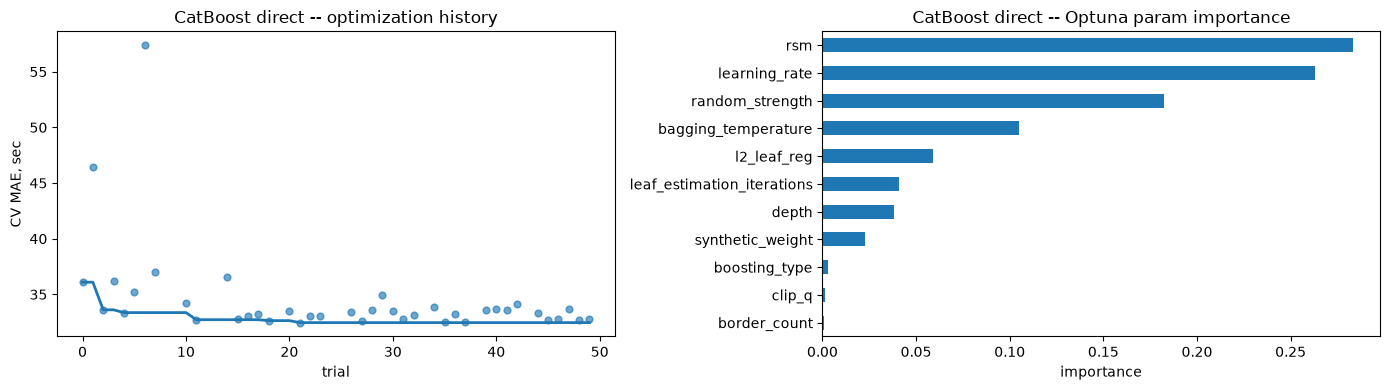

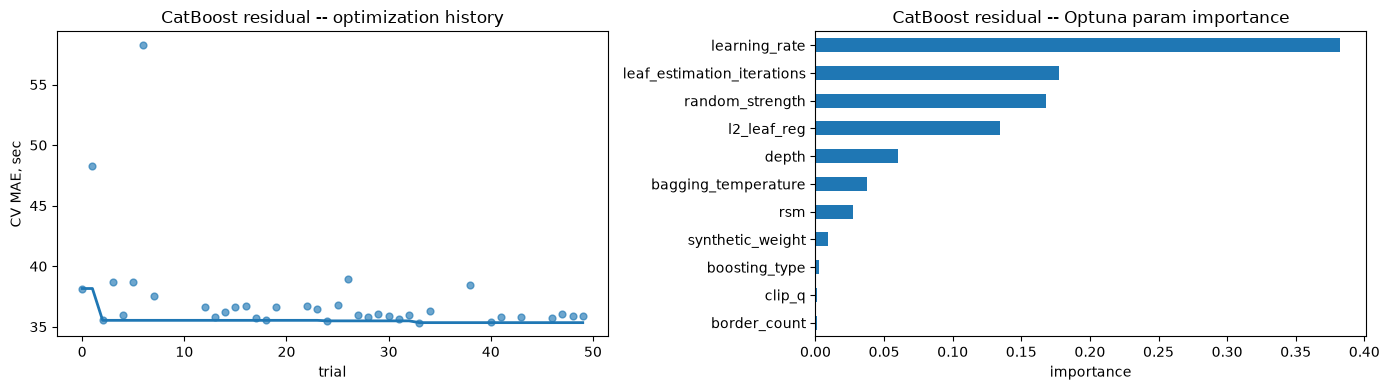

In [11]:
for cat_mode, cat_study in cat_studies.items():
    cat_plot_study(cat_study, f'CatBoost {cat_mode}')

In [13]:
cat_best_mode = cat_study_table.iloc[0]['mode']
cat_best_study = cat_studies[cat_best_mode]
cat_best_params = cat_suggest_params(cat_best_study.best_trial)

pd.Series({
    **cat_best_params,
    'tune_median_best_iteration': cat_best_study.best_trial.user_attrs['median_best_iteration']
}, name='value').to_frame()

,value
depth,8
learning_rate,0.048406
l2_leaf_reg,0.266001
random_strength,0.001837
bagging_temperature,0.46076
rsm,0.811538
border_count,64
leaf_estimation_iterations,1
boosting_type,Ordered
synthetic_weight,0.75


## 5. 5-fold OOF

Повторяю обучение с лучшими параметрами на пяти purged folds. Early stopping работает отдельно в каждом fold. Медиану best iteration потом использую для fit на всем train без подсматривания в test.

In [14]:
def cat_fit_fold(data, x, y, cur_dev, train_idx, valid_idx, mode, params):
    cat_train_part = data.iloc[train_idx]
    cat_weights = cat_sample_weight(cat_train_part, params['synthetic_weight'])
    cat_active = cat_weights > 0

    cat_fit_target = y.iloc[train_idx].loc[cat_active].copy()
    cat_valid_target = y.iloc[valid_idx].copy()
    if mode == 'residual':
        cat_fit_target = cat_fit_target - cur_dev.iloc[train_idx].loc[cat_active]
        cat_valid_target = cat_valid_target - cur_dev.iloc[valid_idx]

    cat_model = cat_make_model(params, CAT_MAX_ITERATIONS, use_best_model=True)
    cat_model.fit(
        x.iloc[train_idx].loc[cat_active],
        cat_fit_target,
        cat_features=cat_categorical_features,
        sample_weight=cat_weights[cat_active],
        eval_set=(x.iloc[valid_idx], cat_valid_target),
        early_stopping_rounds=CAT_EARLY_STOPPING,
        verbose=False
    )

    cat_prediction = cat_model.predict(x.iloc[valid_idx])
    if mode == 'residual':
        cat_prediction += cur_dev.iloc[valid_idx].to_numpy()
    cat_prediction = cat_clip_prediction(
        cat_prediction,
        y.iloc[train_idx].loc[cat_active],
        params['clip_q']
    )
    return cat_model, cat_prediction


def cat_oof_predict(data, x, y, cur_dev, folds, mode, params):
    cat_parts = []
    cat_importances = []
    cat_iterations = []

    for cat_fold, (cat_train_idx, cat_valid_idx) in enumerate(folds):
        cat_model, cat_prediction = cat_fit_fold(
            data, x, y, cur_dev,
            cat_train_idx, cat_valid_idx,
            mode, params
        )
        cat_part = data.iloc[cat_valid_idx][['sample_id', 'tr_id', 'T']].copy()
        cat_part['fold'] = cat_fold
        cat_part['target'] = y.iloc[cat_valid_idx].to_numpy()
        cat_part['prediction'] = cat_prediction
        cat_part['error'] = cat_part.target - cat_part.prediction
        cat_part['abs_error'] = cat_part.error.abs()
        cat_parts.append(cat_part)
        cat_importances.append(pd.Series(
            cat_model.get_feature_importance(),
            index=cat_model_features,
            name=cat_fold
        ))
        cat_iterations.append(cat_model.get_best_iteration() + 1)

    return (
        pd.concat(cat_parts, ignore_index=True),
        pd.concat(cat_importances, axis=1),
        cat_iterations
    )

In [15]:
cat_oof, cat_fold_importance, cat_oof_iterations = cat_oof_predict(
    cat_train,
    cat_x_train,
    cat_y_train,
    cat_cur_train,
    cat_oof_folds,
    cat_best_mode,
    cat_best_params
)
cat_final_iterations = int(np.median(cat_oof_iterations))

pd.Series({
    'oof_mae': cat_oof.abs_error.mean(),
    'oof_median_abs_error': cat_oof.abs_error.median(),
    'oof_p90_abs_error': cat_oof.abs_error.quantile(.9),
    'median_best_iteration': cat_final_iterations
})

oof_mae                    32.840553
oof_median_abs_error       24.803048
oof_p90_abs_error          72.783983
median_best_iteration    2457.000000
dtype: float64

In [16]:
def cat_plot_oof(oof):
    cat_fig, cat_axes = plt.subplots(2, 2, figsize=(14, 10))

    cat_axes[0, 0].scatter(oof.target, oof.prediction, s=18, alpha=.4)
    cat_axes[0, 0].axline((0, 0), slope=1, linestyle='--', linewidth=1)
    cat_axes[0, 0].set_title('OOF -- prediction vs target')
    cat_axes[0, 0].set_xlabel('target, sec')
    cat_axes[0, 0].set_ylabel('prediction, sec')

    cat_axes[0, 1].hist(oof.error, bins=60)
    cat_axes[0, 1].axvline(0, linewidth=1)
    cat_axes[0, 1].set_title('OOF -- error distribution')
    cat_axes[0, 1].set_xlabel('target - prediction, sec')

    cat_fold_mae = oof.groupby('fold').abs_error.mean()
    cat_fold_mae.plot.bar(ax=cat_axes[1, 0])
    cat_axes[1, 0].set_title('MAE по fold')
    cat_axes[1, 0].set_ylabel('MAE, sec')
    cat_axes[1, 0].tick_params(axis='x', rotation=0)

    cat_tr_mae = oof.groupby('tr_id').abs_error.mean().sort_values()
    cat_tr_mae.plot.barh(ax=cat_axes[1, 1])
    cat_axes[1, 1].set_title('MAE по real tr_id')
    cat_axes[1, 1].set_xlabel('MAE, sec')

    plt.tight_layout()

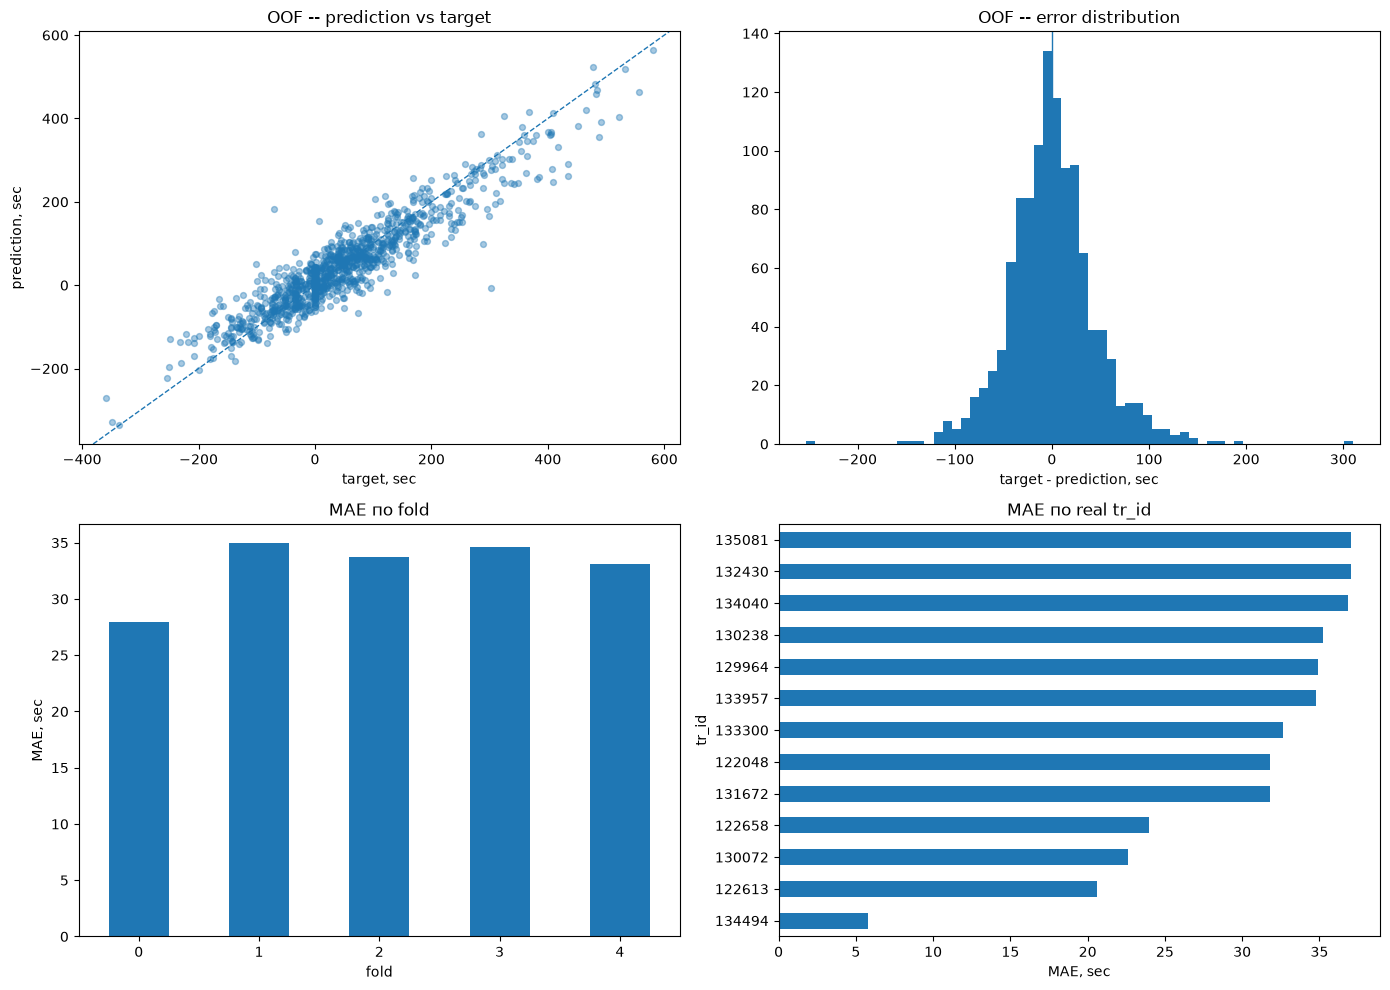

In [17]:
cat_plot_oof(cat_oof)

In [18]:
cat_importance_stability = pd.DataFrame({
    'mean_importance': cat_fold_importance.mean(axis=1),
    'std_importance': cat_fold_importance.std(axis=1)
})
cat_importance_stability['stability_ratio'] = (
    cat_importance_stability.mean_importance
    / (cat_importance_stability.std_importance + 1e-12)
)
cat_importance_stability.sort_values('mean_importance', ascending=False).head(30)

,mean_importance,std_importance,stability_ratio
cur_dev_per_min,4.925963,0.784751,6.277102
current_grid_2,3.478802,0.637520,5.456775
scheduled_stops_per_min,2.987200,0.562353,5.311971
w30m_valid_share,2.925661,0.347799,8.411929
planned_seconds_per_stop,2.881511,0.444793,6.478325
schedule_pos,1.810269,0.349273,5.182963
cur_dev_x_hour_sin,1.715261,0.515583,3.326836
route_proxy_required_speed_kmh,1.603343,0.830392,1.930827
cur_dev_x_w5_speed_signed_log1p,1.493591,0.308264,4.845164
last_valid_lat,1.466365,0.703708,2.083770


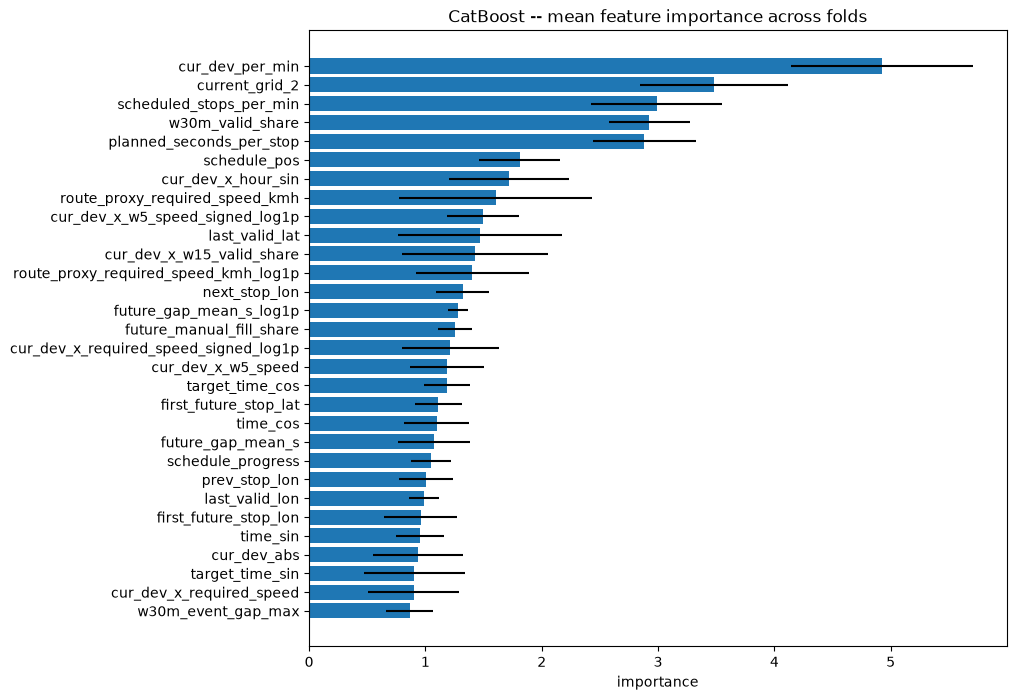

In [19]:
cat_top_importance = cat_importance_stability.nlargest(30, 'mean_importance').sort_values('mean_importance')
plt.figure(figsize=(9, 8))
plt.barh(
    cat_top_importance.index,
    cat_top_importance.mean_importance,
    xerr=cat_top_importance.std_importance
)
plt.title('CatBoost -- mean feature importance across folds')
plt.xlabel('importance')
plt.show()

## 6. Boosting curve на одном purged fold

Это отдельная диагностическая fit на первом fold с уже выбранными параметрами. Test в графике не участвует.

In [20]:
cat_diag_train_idx, cat_diag_valid_idx = cat_oof_folds[0]
cat_diag_model, cat_diag_prediction = cat_fit_fold(
    cat_train,
    cat_x_train,
    cat_y_train,
    cat_cur_train,
    cat_diag_train_idx,
    cat_diag_valid_idx,
    cat_best_mode,
    cat_best_params
)
cat_diag_evals = cat_diag_model.get_evals_result()
cat_diag_curve = pd.DataFrame({
    'train_mae': cat_diag_evals['learn']['MAE'],
    'valid_mae': cat_diag_evals['validation']['MAE']
})
cat_diag_curve.index += 1
cat_diag_curve.index.name = 'iteration'
cat_diag_curve.tail()

,train_mae,valid_mae
iteration,,
2496,10.608364,27.928605
2497,10.598075,27.922445
2498,10.595728,27.914115
2499,10.594322,27.916735
2500,10.594167,27.916302


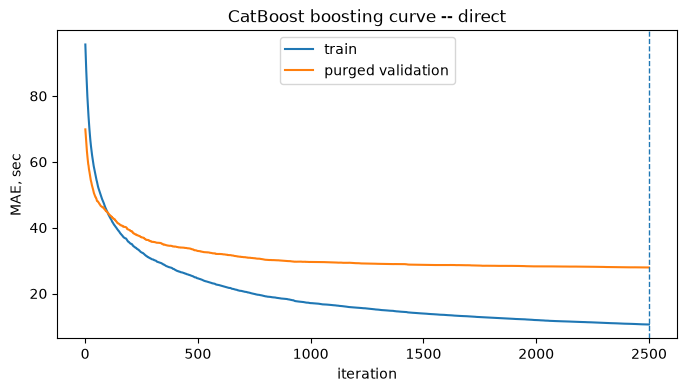

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(cat_diag_curve.index, cat_diag_curve.train_mae, label='train')
plt.plot(cat_diag_curve.index, cat_diag_curve.valid_mae, label='purged validation')
plt.axvline(cat_diag_model.get_best_iteration() + 1, linestyle='--', linewidth=1)
plt.title(f'CatBoost boosting curve -- {cat_best_mode}')
plt.xlabel('iteration')
plt.ylabel('MAE, sec')
plt.legend()
plt.show()

## 7. GroupKFold stress-test

In [22]:
cat_stress_oof, cat_stress_importance, cat_stress_iterations = cat_oof_predict(
    cat_train,
    cat_x_train,
    cat_y_train,
    cat_cur_train,
    cat_stress_folds,
    cat_best_mode,
    cat_best_params
)

pd.Series({
    'purged_oof_mae': cat_oof.abs_error.mean(),
    'unseen_tr_id_mae': cat_stress_oof.abs_error.mean(),
    'stress_median_iteration': int(np.median(cat_stress_iterations))
})

purged_oof_mae               32.840553
unseen_tr_id_mae             33.195417
stress_median_iteration    2362.000000
dtype: float64

## 8. Learning curve

In [23]:
def cat_fraction_mask(data, train_idx, fraction, seed):
    cat_part = data.iloc[train_idx]
    cat_real_idx = cat_part.index[cat_part.tr_id < 9_000_000].to_numpy()
    cat_synthetic_idx = cat_part.index[cat_part.tr_id >= 9_000_000].to_numpy()
    cat_rng = np.random.default_rng(seed)
    cat_score = pd.Series(cat_rng.random(len(cat_real_idx)), index=cat_real_idx)
    cat_selected_real = cat_score.index[cat_score <= fraction].to_numpy()
    return np.concatenate([cat_selected_real, cat_synthetic_idx])

In [24]:
def cat_fit_fixed_iterations(data, x, y, cur_dev, train_idx, valid_idx, mode, params, iterations):
    cat_train_part = data.iloc[train_idx]
    cat_weights = cat_sample_weight(cat_train_part, params['synthetic_weight'])
    cat_active = cat_weights > 0
    cat_fit_target = y.iloc[train_idx].loc[cat_active].copy()
    if mode == 'residual':
        cat_fit_target = cat_fit_target - cur_dev.iloc[train_idx].loc[cat_active]

    cat_model = cat_make_model(params, iterations, use_best_model=False)
    cat_model.fit(
        x.iloc[train_idx].loc[cat_active],
        cat_fit_target,
        cat_features=cat_categorical_features,
        sample_weight=cat_weights[cat_active],
        verbose=False
    )
    cat_prediction = cat_model.predict(x.iloc[valid_idx])
    if mode == 'residual':
        cat_prediction += cur_dev.iloc[valid_idx].to_numpy()
    cat_prediction = cat_clip_prediction(
        cat_prediction,
        y.iloc[train_idx].loc[cat_active],
        params['clip_q']
    )
    return cat_model, cat_prediction


def cat_learning_curve(data, x, y, cur_dev, fold, mode, params, iterations, fractions):
    cat_train_idx, cat_valid_idx = fold
    cat_rows = []

    for cat_fraction in fractions:
        cat_fraction_idx = cat_fraction_mask(data, cat_train_idx, cat_fraction, CAT_SEED)
        _, cat_prediction = cat_fit_fixed_iterations(
            data, x, y, cur_dev,
            cat_fraction_idx, cat_valid_idx,
            mode, params, iterations
        )
        cat_rows.append({
            'real_fraction': cat_fraction,
            'train_rows': len(cat_fraction_idx),
            'valid_mae': mean_absolute_error(y.iloc[cat_valid_idx], cat_prediction)
        })

    return pd.DataFrame(cat_rows)

In [25]:
cat_learning = cat_learning_curve(
    cat_train,
    cat_x_train,
    cat_y_train,
    cat_cur_train,
    cat_oof_folds[0],
    cat_best_mode,
    cat_best_params,
    cat_final_iterations,
    [.2, .4, .6, .8, 1.0]
)
cat_learning

,real_fraction,train_rows,valid_mae
0,0.2,3458,28.242642
1,0.4,3620,27.312016
2,0.6,3793,28.810430
3,0.8,3957,28.927930
4,1.0,4130,27.961194


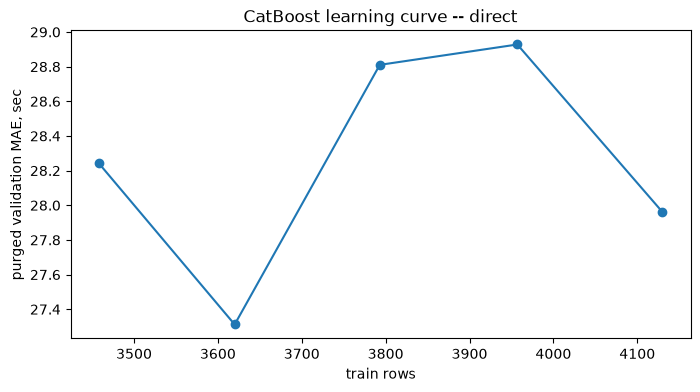

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(cat_learning.train_rows, cat_learning.valid_mae, marker='o')
plt.title(f'CatBoost learning curve -- {cat_best_mode}')
plt.xlabel('train rows')
plt.ylabel('purged validation MAE, sec')
plt.show()

## 9. Official test

Mode, параметры и число итераций уже определены без test. Fit'ю модель на полном train с фиксированным числом деревьев и открываю test один раз.

In [27]:
def cat_fit_full_predict(train_data, train_x, train_y, train_cur, eval_x, eval_cur, mode, params, iterations):
    cat_weights = cat_sample_weight(train_data, params['synthetic_weight'])
    cat_active = cat_weights > 0
    cat_fit_target = train_y.loc[cat_active].copy()
    if mode == 'residual':
        cat_fit_target = cat_fit_target - train_cur.loc[cat_active]

    cat_model = cat_make_model(params, iterations, use_best_model=False)
    cat_model.fit(
        train_x.loc[cat_active],
        cat_fit_target,
        cat_features=cat_categorical_features,
        sample_weight=cat_weights[cat_active],
        verbose=False
    )
    cat_prediction = cat_model.predict(eval_x)
    if mode == 'residual':
        cat_prediction += eval_cur.to_numpy()
    cat_prediction = cat_clip_prediction(
        cat_prediction,
        train_y.loc[cat_active],
        params['clip_q']
    )
    return cat_model, cat_prediction

In [28]:
cat_test_model, cat_test_prediction = cat_fit_full_predict(
    cat_train,
    cat_x_train,
    cat_y_train,
    cat_cur_train,
    cat_x_test,
    cat_cur_test,
    cat_best_mode,
    cat_best_params,
    cat_final_iterations
)

cat_test_metrics = pd.Series({
    'catboost_test_mae': mean_absolute_error(cat_y_test, cat_test_prediction),
    'cur_dev_test_mae': mean_absolute_error(cat_y_test, cat_cur_test),
    'improvement_sec': mean_absolute_error(cat_y_test, cat_cur_test)
        - mean_absolute_error(cat_y_test, cat_test_prediction)
})
cat_test_metrics

catboost_test_mae    35.232750
cur_dev_test_mae     93.359773
improvement_sec      58.127023
dtype: float64

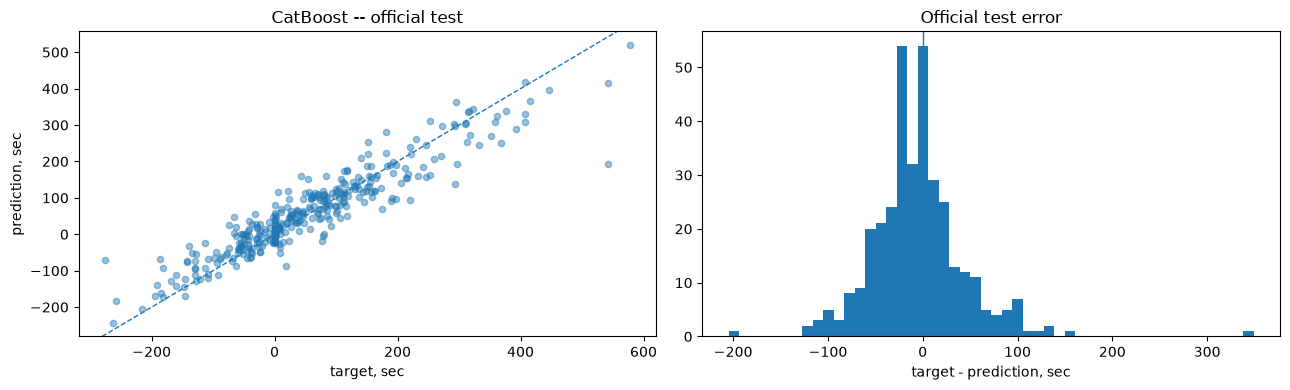

In [29]:
cat_test_error = cat_y_test.to_numpy() - cat_test_prediction
cat_fig, cat_axes = plt.subplots(1, 2, figsize=(13, 4))
cat_axes[0].scatter(cat_y_test, cat_test_prediction, s=20, alpha=.45)
cat_axes[0].axline((0, 0), slope=1, linestyle='--', linewidth=1)
cat_axes[0].set_title('CatBoost -- official test')
cat_axes[0].set_xlabel('target, sec')
cat_axes[0].set_ylabel('prediction, sec')
cat_axes[1].hist(cat_test_error, bins=50)
cat_axes[1].axvline(0, linewidth=1)
cat_axes[1].set_title('Official test error')
cat_axes[1].set_xlabel('target - prediction, sec')
plt.tight_layout()

## 10. SHAP на official test

SHAP здесь использую только для интерпретации уже зафиксированной модели. Это не этап отбора гиперпараметров.

In [30]:
cat_shap_values = cat_test_model.get_feature_importance(
    Pool(cat_x_test, cat_features=cat_categorical_features),
    type='ShapValues'
)
cat_shap_importance = pd.Series(
    np.abs(cat_shap_values[:, :-1]).mean(axis=0),
    index=cat_model_features,
    name='mean_abs_shap'
).sort_values(ascending=False)
cat_shap_importance.head(30).to_frame()

,mean_abs_shap
current_grid_2,12.285487
w30m_valid_share,9.111506
planned_seconds_per_stop,8.138253
target_grid_4,6.605406
cur_dev_s,6.076759
cur_dev_per_min,5.766102
cur_dev_x_w5_speed_signed_log1p,5.158603
future_gap_mean_s,4.588346
cur_dev_sqrt,4.483636
route_proxy_required_speed_kmh,4.396902


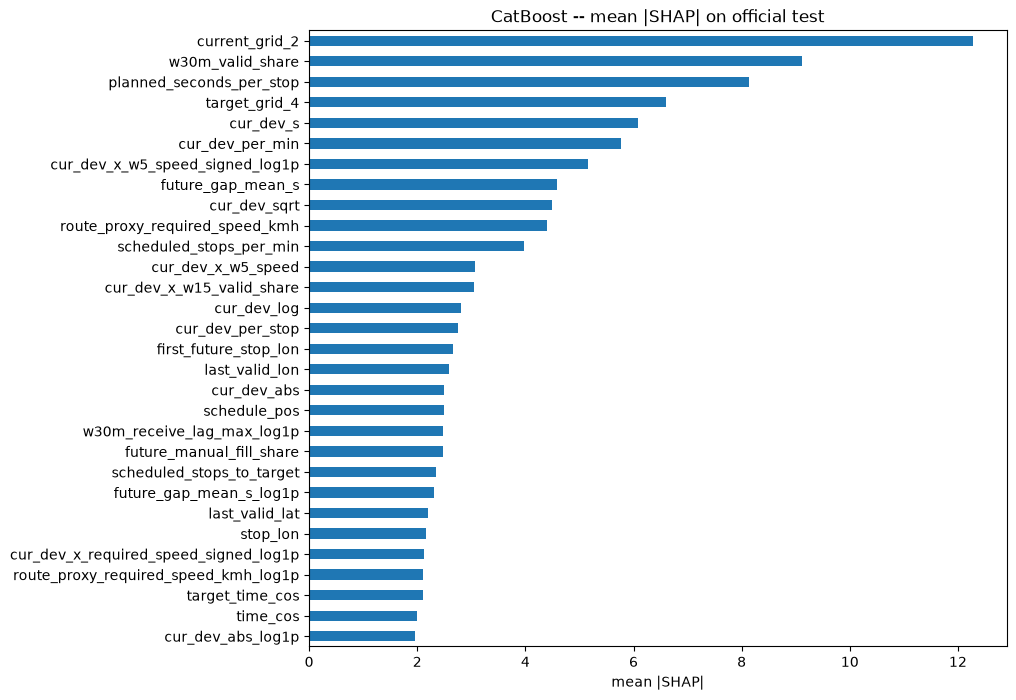

In [31]:
cat_shap_importance.head(30).sort_values().plot.barh(figsize=(9, 8))
plt.title('CatBoost -- mean |SHAP| on official test')
plt.xlabel('mean |SHAP|')
plt.show()

## 11. Final retune на train + test

После test audit объединяю все доступные labels. Запускаю короткий второй search в уже выбранном mode. Для финальной модели число деревьев снова определяю только по CV на объединенной размеченной выборке.

In [32]:
cat_all = pd.concat([cat_train, cat_test], ignore_index=True)
cat_x_all = cat_prepare_frame(cat_all)
cat_y_all = cat_all.target_delay_s.astype(float)
cat_cur_all = cat_all.cur_dev_s.astype(float)
cat_final_folds = cat_build_purged_folds(cat_all, CAT_OOF_FOLDS, CAT_PURGE_MINUTES)

cat_final_study = optuna.create_study(
    study_name=f'cat_{cat_best_mode}_final',
    storage=cat_storage,
    load_if_exists=True,
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=CAT_SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)
if len(cat_final_study.trials) == 0:
    cat_final_study.enqueue_trial(cat_best_study.best_params)

cat_final_remaining = max(0, CAT_FINAL_TRIALS - len(cat_final_study.trials))
if cat_final_remaining:
    cat_final_study.optimize(
        lambda cat_trial: cat_objective(
            cat_trial,
            cat_best_mode,
            cat_all,
            cat_x_all,
            cat_y_all,
            cat_cur_all,
            cat_final_folds
        ),
        n_trials=cat_final_remaining,
        n_jobs=1,
        show_progress_bar=True
    )

cat_final_params = cat_suggest_params(cat_final_study.best_trial)
pd.Series(cat_final_params, name='value').to_frame()

[I 2026-09-27 11:46:39,225] A new study created in RDB with name: cat_direct_final
Best trial: 0. Best value: 33.6099:   4%|▍         | 1/24 [05:30<2:06:52, 331.00s/it]

[I 2026-09-27 11:52:10,228] Trial 0 finished with value: 33.609933134244926 and parameters: {'depth': 8, 'learning_rate': 0.04840594356146787, 'l2_leaf_reg': 0.26600080650077107, 'random_strength': 0.001836797821065186, 'bagging_temperature': 0.4607596934865099, 'rsm': 0.8115375229068852, 'border_count': 64, 'leaf_estimation_iterations': 1, 'boosting_type': 'Ordered', 'synthetic_weight': 0.75, 'clip_q': 0.001}. Best is trial 0 with value: 33.609933134244926.


Best trial: 0. Best value: 33.6099:   8%|▊         | 2/24 [18:42<3:40:45, 602.09s/it]

[I 2026-09-27 12:05:22,085] Trial 1 finished with value: 36.56053893628189 and parameters: {'depth': 9, 'learning_rate': 0.02671381038052399, 'l2_leaf_reg': 0.7453502534740668, 'random_strength': 0.04963088992767007, 'bagging_temperature': 2.8415980689029667, 'rsm': 0.9406404290814394, 'border_count': 254, 'leaf_estimation_iterations': 2, 'boosting_type': 'Plain', 'synthetic_weight': 0.25, 'clip_q': 0.005}. Best is trial 0 with value: 33.609933134244926.


Best trial: 0. Best value: 33.6099:  12%|█▎        | 3/24 [21:08<2:17:49, 393.77s/it]

...

Best trial: 16. Best value: 32.6396:  96%|█████████▌| 23/24 [3:11:47<09:23, 563.47s/it]

[I 2026-09-27 14:58:27,160] Trial 22 finished with value: 33.23983827322809 and parameters: {'depth': 10, 'learning_rate': 0.03242944489342832, 'l2_leaf_reg': 0.04434193206507016, 'random_strength': 0.6007228245440526, 'bagging_temperature': 2.246483542248362, 'rsm': 0.8597401894524996, 'border_count': 64, 'leaf_estimation_iterations': 2, 'boosting_type': 'Ordered', 'synthetic_weight': 0.75, 'clip_q': 0.001}. Best is trial 16 with value: 32.639609826992.


Best trial: 16. Best value: 32.6396: 100%|██████████| 24/24 [3:29:55<00:00, 524.80s/it]

[I 2026-09-27 15:16:34,339] Trial 23 finished with value: 33.055092274598096 and parameters: {'depth': 10, 'learning_rate': 0.05162949964165707, 'l2_leaf_reg': 15.031488403852249, 'random_strength': 0.01661505926027974, 'bagging_temperature': 2.445008391381627, 'rsm': 0.8994423978023751, 'border_count': 64, 'leaf_estimation_iterations': 1, 'boosting_type': 'Ordered', 'synthetic_weight': 0.75, 'clip_q': 0.001}. Best is trial 16 with value: 32.639609826992.


,value
depth,9
learning_rate,0.044888
l2_leaf_reg,0.513859
random_strength,0.241994
bagging_temperature,2.041238
rsm,0.847137
border_count,64
leaf_estimation_iterations,1
boosting_type,Ordered
synthetic_weight,0.75


In [33]:
cat_final_oof, cat_final_importance, cat_final_iterations_by_fold = cat_oof_predict(
    cat_all,
    cat_x_all,
    cat_y_all,
    cat_cur_all,
    cat_final_folds,
    cat_best_mode,
    cat_final_params
)
cat_validate_iterations = int(np.median(cat_final_iterations_by_fold))

pd.Series({
    'final_cv_mae': cat_final_oof.abs_error.mean(),
    'final_iterations': cat_validate_iterations
})

final_cv_mae          32.630213
final_iterations    2477.000000
dtype: float64

## 12. Final fit и submission

In [34]:
cat_final_model, cat_validate_prediction = cat_fit_full_predict(
    cat_all,
    cat_x_all,
    cat_y_all,
    cat_cur_all,
    cat_x_validate,
    cat_cur_validate,
    cat_best_mode,
    cat_final_params,
    cat_validate_iterations
)

cat_submission_dir = Path('../submissions/catboost')
cat_submission_dir.mkdir(parents=True, exist_ok=True)
cat_submission_template = pd.read_csv('../dataset/sample_submission.csv', sep=';')
cat_pred_map = pd.Series(cat_validate_prediction, index=cat_validate.sample_id)
cat_submission = cat_submission_template.copy()
cat_submission['prediction'] = cat_submission.sample_id.map(cat_pred_map)
assert cat_submission.prediction.notna().all()
assert cat_submission.sample_id.is_unique

cat_submission_path = cat_submission_dir / f'catboost_optuna_{cat_best_mode}.csv'
cat_submission.to_csv(cat_submission_path, sep=';', index=False)
cat_submission_path

PosixPath('../submissions/catboost/catboost_optuna_direct.csv')

In [35]:
cat_oof.to_csv(cat_artifact_dir / 'oof_train.csv', index=False)
cat_stress_oof.to_csv(cat_artifact_dir / 'oof_group_stress.csv', index=False)
cat_importance_stability.to_csv(cat_artifact_dir / 'feature_importance_stability.csv')
cat_shap_importance.to_csv(cat_artifact_dir / 'shap_test.csv')
cat_study_table.to_csv(cat_artifact_dir / 'study_summary.csv', index=False)
cat_test_metrics.rename('value').to_csv(cat_artifact_dir / 'test_metrics.csv')

pd.Series({
    'selected_mode': cat_best_mode,
    'train_cv_mae': cat_oof.abs_error.mean(),
    'group_stress_mae': cat_stress_oof.abs_error.mean(),
    'official_test_mae': mean_absolute_error(cat_y_test, cat_test_prediction),
    'final_labeled_cv_mae': cat_final_oof.abs_error.mean(),
    'submission': str(cat_submission_path)
})

selected_mode                                                      direct
train_cv_mae                                                    32.840553
group_stress_mae                                                33.195417
official_test_mae                                                35.23275
final_labeled_cv_mae                                            32.630213
submission              ../submissions/catboost/catboost_optuna_direct...
dtype: object

In [36]:
cat_checkpoint_dir = cat_artifact_dir / 'checkpoints'
cat_checkpoint_dir.mkdir(parents=True, exist_ok=True)

cat_model_path = cat_checkpoint_dir / 'catboost_final.cbm'
cat_final_model.save_model(cat_model_path)

cat_model_path

PosixPath('../artifacts/models/catboost/checkpoints/catboost_final.cbm')